# A shift-aware trade-off map of four trustworthiness properties

**Do predictive performance, calibration, and group fairness degrade *together* under
distribution shift, or do they move independently?**

Using the same temporal × geographic grid as the early-warning test (train on CA-2014, evaluate
on 12 states × 2014–2018, 3 tasks, 3 models = 531 domains), this notebook audits four properties
of each classifier in-distribution and under shift. It loads the saved audit table; the pipeline
is `../../week3_audit.py`.

### Result
The four properties **do not move as one axis.** Performance metrics cluster and the two fairness
metrics cluster, but **calibration is statistically independent of accuracy**, and **fairness
gaps trade off against accuracy.** Most importantly, in domains where *accuracy barely changes*,
calibration and fairness **still degrade** — so **accuracy alone is a weak proxy for
trustworthiness under shift.** Full write-up: `../WEEK3_AUDIT_FINDINGS.md`.


## Setup

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11, "axes.titleweight": "bold"})

def repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "results" / "week3_audit_full.csv").exists():
            return base
    raise FileNotFoundError("Run from inside the trustworthy-shift repository.")
ROOT = repo_root()
df = pd.read_csv(ROOT / "results" / "week3_audit_full.csv")

# per-domain CHANGE under shift (positive = the property got worse)
df["acc_drop"]    = df["acc_src"]    - df["acc_tgt"]
df["auc_drop"]    = df["auc_src"]    - df["auc_tgt"]
df["ECE_inc"]     = df["ace_tgt"]    - df["ace_src"]
df["DPgap_sex_inc"]  = df["dp_sex_tgt"] - df["dp_sex_src"]
df["DPgap_race_inc"] = df["dp_rac_tgt"] - df["dp_rac_src"]
print(f"{len(df)} domains | tasks={df.task.nunique()} models={df.model.nunique()} states={df.state.nunique()}")


531 domains | tasks=3 models=3 states=12


## 1. Under shift, every property degrades — calibration most of all

Averaged over all shifted domains. Calibration error (ECE) increases *more* than accuracy falls,
the first sign that accuracy understates the damage.

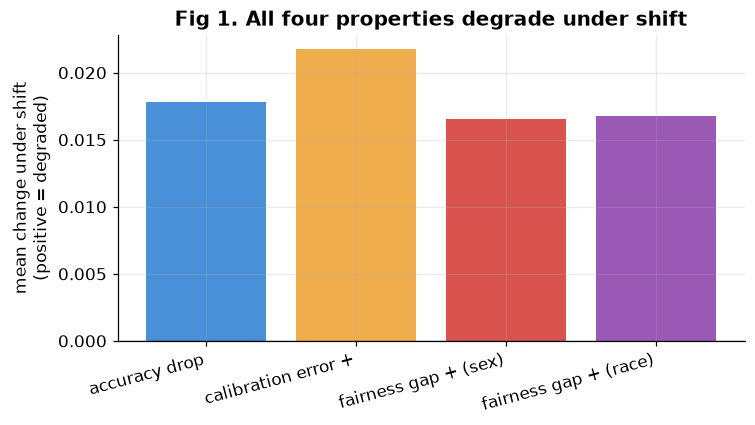

In [2]:
props = ["acc_drop", "ECE_inc", "DPgap_sex_inc", "DPgap_race_inc"]
labels = ["accuracy drop", "calibration error +", "fairness gap + (sex)", "fairness gap + (race)"]
means = [df[p].mean() for p in props]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, means, color=["#4a90d9", "#f0ad4e", "#d9534f", "#9b59b6"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("mean change under shift\n(positive = degraded)")
ax.set_title("Fig 1. All four properties degrade under shift")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()


## 2. The trade-off map: do they move together?

Correlation (Spearman) of the per-domain *changes*. If everything degraded in lock-step, this
would be uniformly positive. It is not.

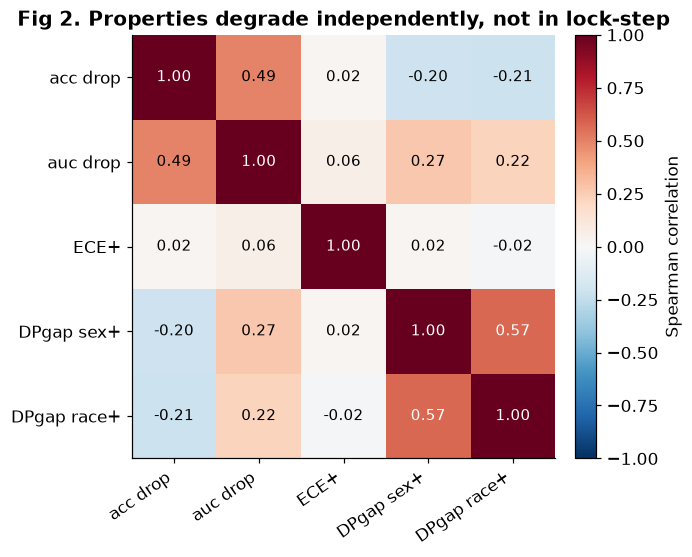

In [3]:
cols = ["acc_drop", "auc_drop", "ECE_inc", "DPgap_sex_inc", "DPgap_race_inc"]
short = ["acc drop", "auc drop", "ECE+", "DPgap sex+", "DPgap race+"]
C = df[cols].corr(method="spearman").to_numpy()

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(short))); ax.set_xticklabels(short, rotation=35, ha="right")
ax.set_yticks(range(len(short))); ax.set_yticklabels(short)
for i in range(len(short)):
    for j in range(len(short)):
        ax.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(C[i,j])>0.55 else "black", fontsize=10)
ax.grid(False)
fig.colorbar(im, fraction=0.046, pad=0.04, label="Spearman correlation")
ax.set_title("Fig 2. Properties degrade independently, not in lock-step")
plt.tight_layout(); plt.show()


**Read the map:**
- Performance metrics cluster (`acc drop` ↔ `auc drop` ≈ +0.5) and the two fairness gaps cluster
  (≈ +0.6) — internally coherent.
- **Calibration is decoupled from accuracy** (`acc drop` ↔ `ECE+` ≈ 0): knowing accuracy fell
  tells you almost nothing about whether calibration fell.
- **Fairness trades off against accuracy** (`acc drop` ↔ `DPgap+` ≈ −0.2): where accuracy holds,
  fairness gaps tend to widen more.

So "trustworthiness" is not one axis — you must measure the properties separately.

## 3. The decisive test — accuracy is a weak proxy

Take only the domains where **accuracy barely moved** (|Δacc| < 1 percentage point). If accuracy
were a good proxy, the other properties should be stable too. They are not.

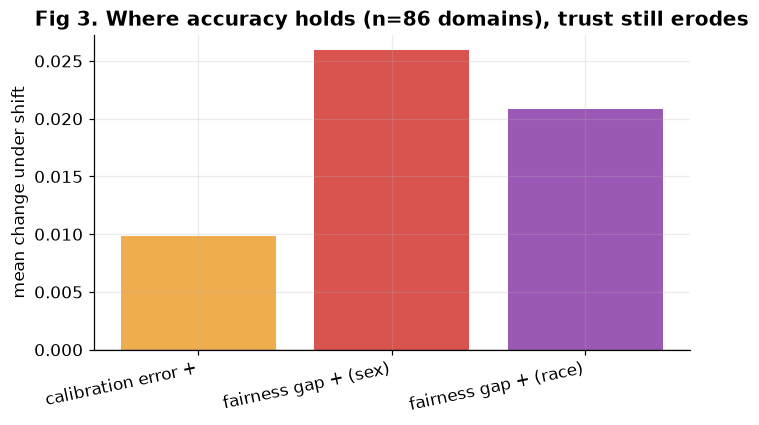

In 86 accuracy-stable domains: ECE still +0.0098, DP-gap(sex) +0.0260, DP-gap(race) +0.0208


In [4]:
stable = df[df["acc_drop"].abs() < 0.01]
vals = [stable["ECE_inc"].mean(), stable["DPgap_sex_inc"].mean(), stable["DPgap_race_inc"].mean()]
labs = ["calibration error +", "fairness gap + (sex)", "fairness gap + (race)"]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(labs, vals, color=["#f0ad4e", "#d9534f", "#9b59b6"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("mean change under shift")
ax.set_title(f"Fig 3. Where accuracy holds (n={len(stable)} domains), trust still erodes")
plt.xticks(rotation=12, ha="right"); plt.tight_layout(); plt.show()
print(f"In {len(stable)} accuracy-stable domains: ECE still +{vals[0]:.4f}, "
      f"DP-gap(sex) +{vals[1]:.4f}, DP-gap(race) +{vals[2]:.4f}")


## 4. Heterogeneity — which task / model degrades on what

The trade-offs differ by task and model, which is the substance of the map.

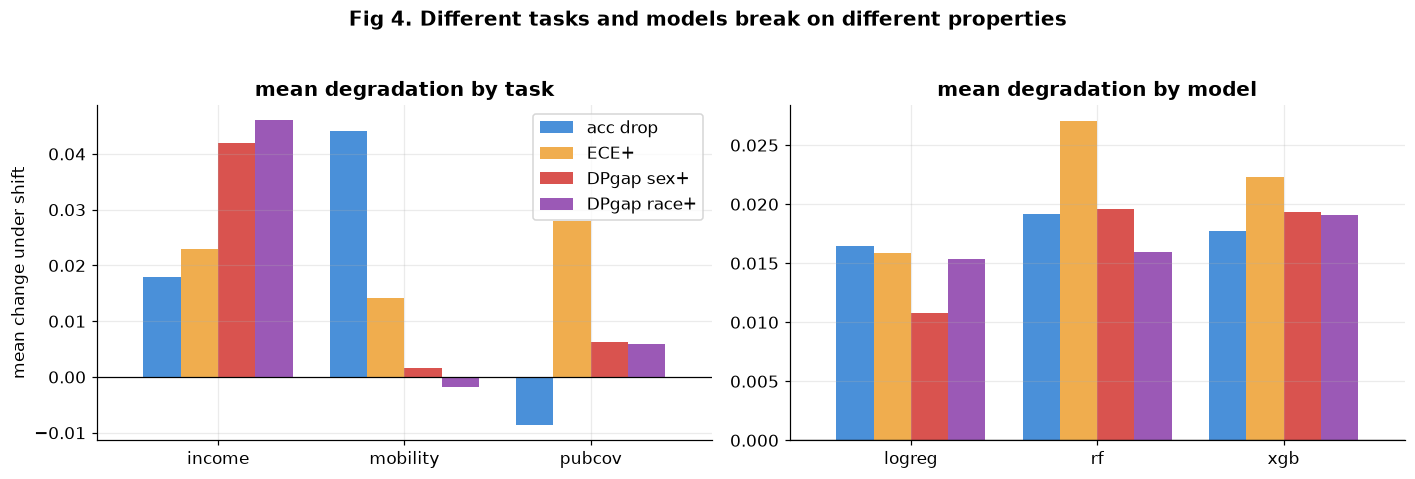

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, by in zip(axes, ["task", "model"]):
    g = df.groupby(by)[["acc_drop", "ECE_inc", "DPgap_sex_inc", "DPgap_race_inc"]].mean()
    g.columns = ["acc drop", "ECE+", "DPgap sex+", "DPgap race+"]
    g.plot(kind="bar", ax=ax, width=0.8,
           color=["#4a90d9", "#f0ad4e", "#d9534f", "#9b59b6"], legend=(by=="task"))
    ax.axhline(0, color="black", lw=0.8); ax.set_title(f"mean degradation by {by}")
    ax.set_xlabel(""); plt.setp(ax.get_xticklabels(), rotation=0)
axes[0].set_ylabel("mean change under shift")
fig.suptitle("Fig 4. Different tasks and models break on different properties",
             y=1.03, fontweight="bold")
plt.tight_layout(); plt.show()


Notable: **income** degrades on everything (fairness most); **mobility** loses the most
accuracy but fairness barely moves; **pubcov** accuracy slightly *improves* yet calibration
degrades most. The simple **logreg** is the most calibration/fairness-robust; **rf/xgb** degrade
more — model complexity costs trustworthiness-robustness.

## 5. Does in-distribution recalibration survive the shift?

We fit an isotonic recalibrator on the source (CA-2014) validation set and apply it to each
shifted target. It only partly helps — calibration learned in-distribution does **not** transfer
well under shift.

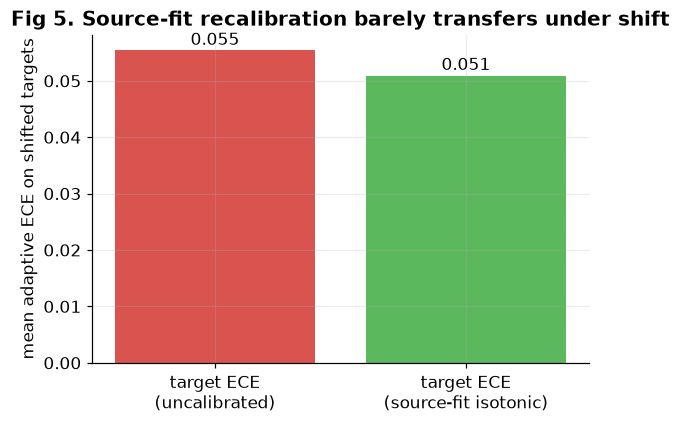

In [6]:
before = df["ace_tgt"].mean(); after = df["ace_iso_tgt"].mean()
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["target ECE\n(uncalibrated)", "target ECE\n(source-fit isotonic)"], [before, after],
       color=["#d9534f", "#5cb85c"])
ax.set_ylabel("mean adaptive ECE on shifted targets")
ax.set_title("Fig 5. Source-fit recalibration barely transfers under shift")
for i, v in enumerate([before, after]):
    ax.text(i, v + 0.001, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()


## 6. Caveats & conclusion

**Caveats (carried into the paper's limitations):**
- The **accuracy ↔ fairness trade-off may be partly mechanical**: a model degrading toward random
  predictions naturally shows smaller group disparities, so a shrinking gap is not necessarily a
  benefit. It is reported as a correlation and flagged, not sold as a free lunch.
- Effect sizes are modest (|0.2–0.5|); the robust claim is the **decoupling** of accuracy from
  calibration/fairness, shown most cleanly by the accuracy-stable slice (§3).
- One data family (US census); `mobility` is near-chance (AUC ≈ 0.57); fairness uses binarized
  SEX and RACE (White / non-White).

**Conclusion.** Under temporal and geographic shift, the four trustworthiness properties degrade
**independently**: accuracy carries little information about calibration or fairness, and where
accuracy holds, calibration and fairness still erode. A single-metric (accuracy) audit is
therefore insufficient. Together with the pre-registered early-warning **NO-GO**
(`01_early_warning_test.ipynb`), this trade-off map is the empirical core of the paper.

---
Findings: [`../WEEK3_AUDIT_FINDINGS.md`](../WEEK3_AUDIT_FINDINGS.md) ·
Pipeline: [`../../week3_audit.py`](../../week3_audit.py) ·
Data: [`../week3_audit_full.csv`](../week3_audit_full.csv) ·
Early-warning test: [`01_early_warning_test.ipynb`](01_early_warning_test.ipynb)
